In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import laion_clap

/Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <ABE0EE74-6D97-3B8C-B690-C44754774FBC> /Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torchvision/image.so
  Expected in:     <C2312207-5AC4-3902-AAC5-BF172CB5566E> /Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torchvision/datapoints/__

In [3]:
model = laion_clap.CLAP_Module(enable_fusion=False)
model.load_ckpt() # download the default pretrained checkpoint.

/Users/siliu/miniconda3/envs/torch-gpu-research/lib/python3.8/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1708241831999/work/aten/src/ATen/native/TensorShape.cpp:3560.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

# make audio embedding

In [4]:
import torch
def make_emb(enc_model, audio_48khz_1D, trim=None):
    """
    input: batch, len(audio_wave)
    output: batch, token_dim1, token_dim2
    """
    if trim is not None:
        audio_48khz_1D = audio_48khz_1D[:trim]
    emb = enc_model.get_audio_embedding_from_data(x = np.array(audio_48khz_1D), use_tensor=False)
    return emb

In [5]:
object_list = sorted(['cane-sugar', 'chia-seed', 'chickpea', 'detergent', 'empty',
               'glass-bead', 'kidney-bean', 'metal-nut-bolt', 'plastic-bead',
               'salt', 'split-green-pea', 'styrofoam-bead', 'water', 'wheat',
               'wooden-button'])

In [16]:
# Root folder path
root_folder = "/Users/siliu/Desktop/Tool_Dataset_Sample_HPC"  # Change this to your actual folder path
behaviors = ['2-stirring-slow', '3-stirring-fast','4-stirring-twist', '5-whisk', '6-poke']
all_tools = ['metal-scissor', 'metal-whisk', 'plastic-knife', 'plastic-spoon', 'wooden-chopstick', 'wooden-fork']

In [17]:
import os
import librosa
root_len = len(root_folder.split(os.sep))

robot = {beh: {tool: {obj: [] for obj in object_list} for tool in all_tools} for beh in behaviors}
audio_sample_rate = 48000   # CLAP default
DURATION = 20  # 20 seconds

for root, dirs, files in os.walk(root_folder):
    path_parts = root.split(os.sep)
    if len(path_parts) == (root_len + 5):  # Ensure it matches the expected depth to the modality folder
        tool, obj, trial, behavior, modality = path_parts[-5:]
        tool = tool.split("_")[1]
        if behavior in behaviors:
            for file in files:
                if file.endswith('.wav'):  # Only process .wav files
                    print(tool, obj, trial, behavior, modality)
                    audio_file_path = os.path.join(root, file)
                    label = object_list.index(obj)  # Get label for object
                    audio_data, _ = librosa.load(audio_file_path, sr=audio_sample_rate, duration=DURATION)
                    audio_data = np.array([audio_data])
                    audio_embed = make_emb(enc_model=model, audio_48khz_1D=audio_data).squeeze()
                    robot[behavior][tool][obj].append(audio_embed) # Save trial data

metal-whisk cane-sugar trial-7_23-12-2022-23-40-03 6-poke audio
metal-whisk cane-sugar trial-7_23-12-2022-23-40-03 4-stirring-twist audio
metal-whisk cane-sugar trial-7_23-12-2022-23-40-03 2-stirring-slow audio
metal-whisk cane-sugar trial-7_23-12-2022-23-40-03 5-whisk audio
metal-whisk cane-sugar trial-7_23-12-2022-23-40-03 3-stirring-fast audio
metal-whisk cane-sugar trial-2_21-12-2022-07-41-07 6-poke audio
metal-whisk cane-sugar trial-2_21-12-2022-07-41-07 4-stirring-twist audio
metal-whisk cane-sugar trial-2_21-12-2022-07-41-07 2-stirring-slow audio
metal-whisk cane-sugar trial-2_21-12-2022-07-41-07 5-whisk audio
metal-whisk cane-sugar trial-2_21-12-2022-07-41-07 3-stirring-fast audio
metal-whisk cane-sugar trial-1_20-12-2022-20-21-38 6-poke audio
metal-whisk cane-sugar trial-1_20-12-2022-20-21-38 4-stirring-twist audio
metal-whisk cane-sugar trial-1_20-12-2022-20-21-38 2-stirring-slow audio
metal-whisk cane-sugar trial-1_20-12-2022-20-21-38 5-whisk audio
metal-whisk cane-sugar tri

In [18]:
import copy
emb_dict = copy.deepcopy(robot)
for beh in behaviors:
    for t in all_tools:
        for o in object_list:
            emb_dict[beh][t][o] = np.array(robot[beh][t][o])

In [28]:
np.savez("audio_20s_clap_emb_all.npz", **emb_dict)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_emb_dict_tsne(emb_dict):
    # Collect all embeddings
    all_embeddings = []
    labels_behavior = []
    labels_tool = []
    labels_obj = []
    
    for behavior, tools in emb_dict.items():
        for tool, objs in tools.items():
            for obj, mat in objs.items():
                mat = np.array(mat)  # (n_trials, 512)
                all_embeddings.append(mat)
                labels_behavior.extend([behavior] * mat.shape[0])
                labels_tool.extend([tool] * mat.shape[0])
                labels_obj.extend([obj] * mat.shape[0])
    
    all_embeddings = np.vstack(all_embeddings)  # (N, 512)
    
    # Reduce dimension with t-SNE
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    reduced = tsne.fit_transform(all_embeddings)  # (N, 2)
    
    # Setup for plotting
    unique_behaviors = sorted(set(labels_behavior))
    unique_objs = sorted(set(labels_obj))
    unique_tools = sorted(set(labels_tool))
    
    # Colors by obj
    palette = sns.color_palette("tab20", len(unique_objs))
    obj_to_color = {obj: palette[i] for i, obj in enumerate(unique_objs)}
    
    # Shapes by tool
    markers = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">"]
    tool_to_marker = {tool: markers[i % len(markers)] for i, tool in enumerate(unique_tools)}
    
    # Plot, one row per behavior
    fig, axes = plt.subplots(len(unique_behaviors), 1, figsize=(10, 6 * len(unique_behaviors)))
    if len(unique_behaviors) == 1:
        axes = [axes]  # ensure iterable
    
    for ax, behavior in zip(axes, unique_behaviors):
        mask = [b == behavior for b in labels_behavior]
        x = reduced[mask, 0]
        y = reduced[mask, 1]
        objs = np.array(labels_obj)[mask]
        tools = np.array(labels_tool)[mask]
        
        # Scatter points
        for xi, yi, tool, obj in zip(x, y, tools, objs):
            ax.scatter(
                xi, yi,
                c=[obj_to_color[obj]],
                marker=tool_to_marker[tool],
                alpha=0.7
            )
        
        ax.set_title(f"Behavior: {behavior}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        
        # Legends
        # Objects (colors)
        obj_handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       label=obj, markerfacecolor=obj_to_color[obj], markersize=8)
            for obj in unique_objs
        ]
        # Tools (shapes)
        tool_handles = [
            plt.Line2D([0], [0], marker=tool_to_marker[tool], color='k',
                       label=tool, linestyle='None', markersize=8)
            for tool in unique_tools
        ]
        
        legend1 = ax.legend(handles=obj_handles, title="Objects",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
        legend2 = ax.legend(handles=tool_handles, title="Tools",
                            bbox_to_anchor=(1.05, 0.3), loc="upper left")
        ax.add_artist(legend1)  # keep both legends
    
    plt.tight_layout()
    plt.show()

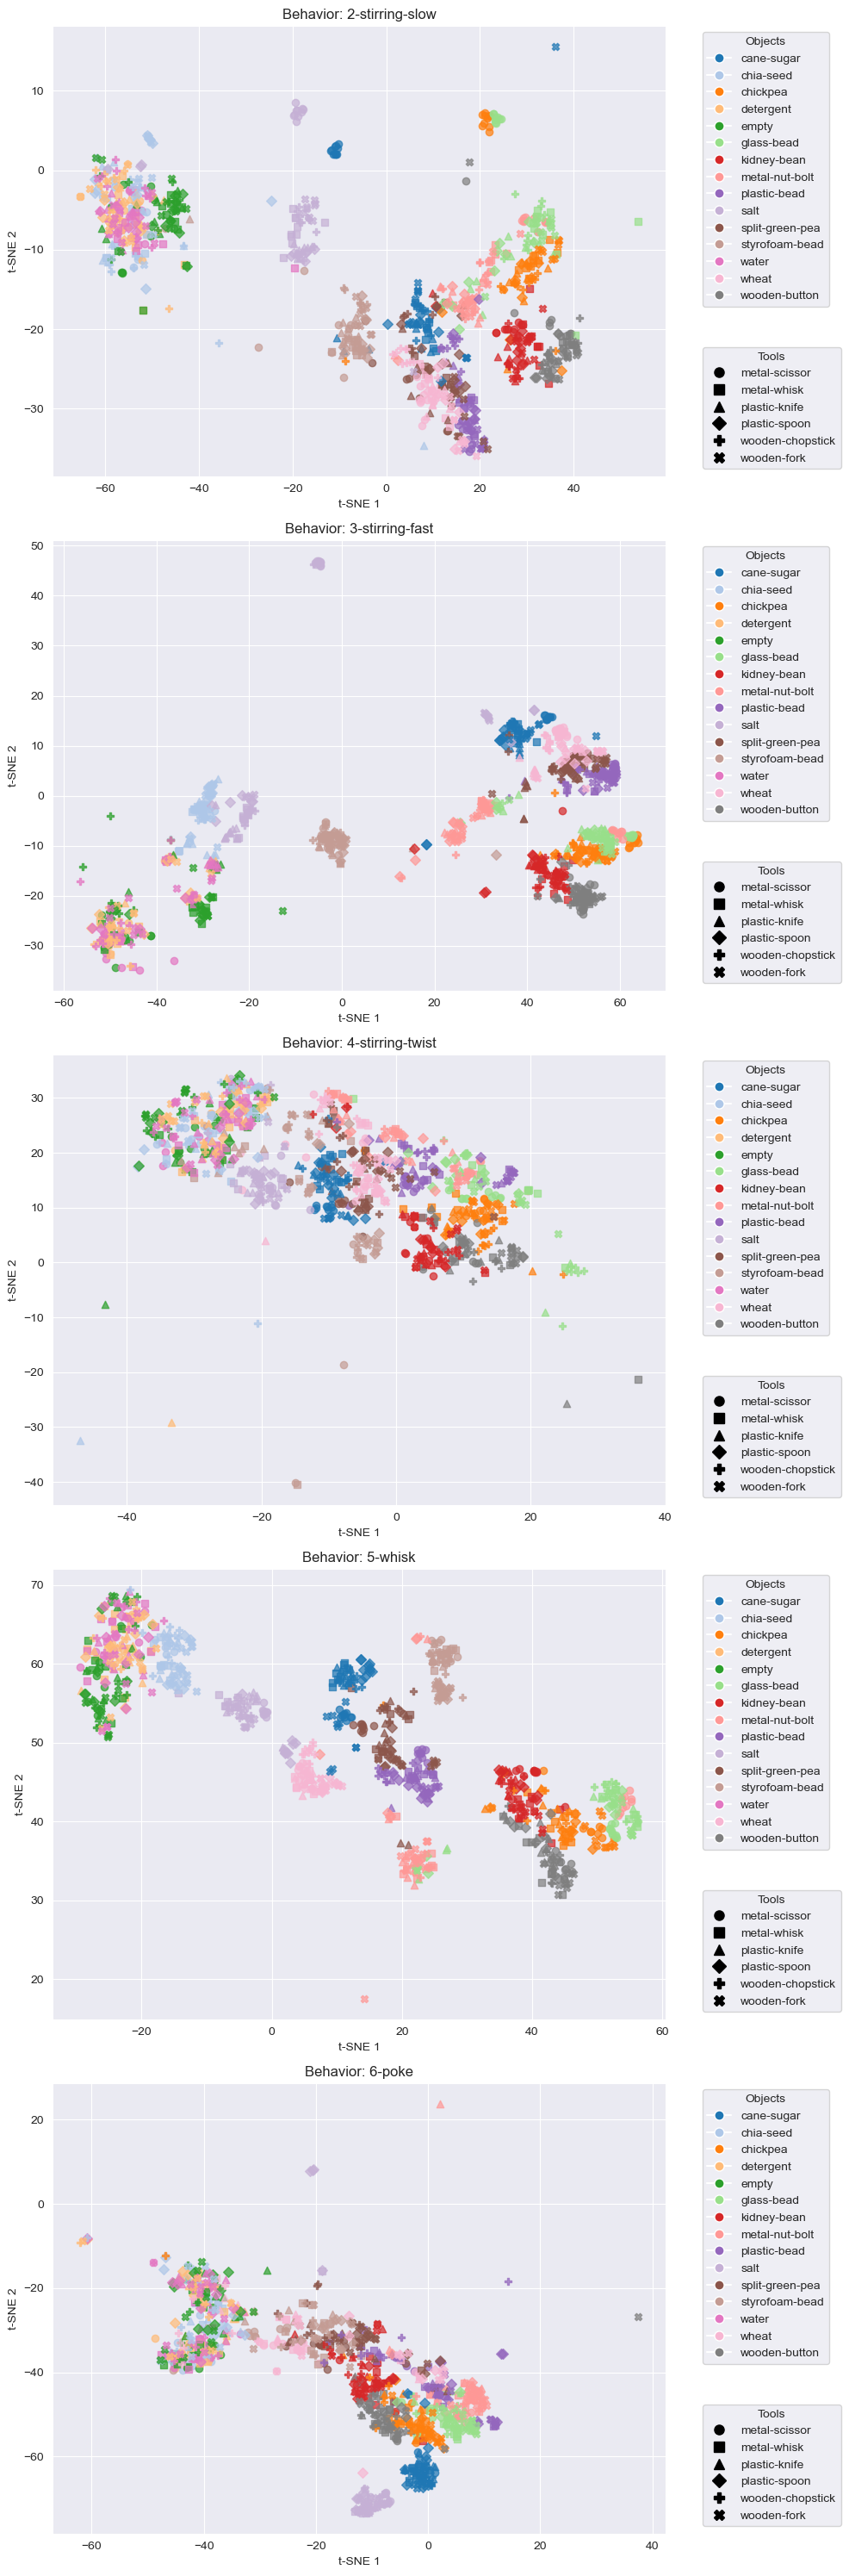

In [21]:
plot_emb_dict_tsne(emb_dict)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_emb_behavior_tsne(emb_dict, behavior_name: str):
    """
    Plot t-SNE of embeddings for a single behavior.
    
    Args:
        emb_dict: dict[behavior][tool][object] -> np.ndarray (n_trials, emb_dim)
        behavior_name: str, behavior key in emb_dict
    """
    if behavior_name not in emb_dict:
        raise ValueError(f"Behavior '{behavior_name}' not found. "
                         f"Available: {list(emb_dict.keys())}")
    
    # Collect embeddings only for this behavior
    all_embeddings = []
    labels_tool = []
    labels_obj = []
    
    for tool, objs in emb_dict[behavior_name].items():
        for obj, mat in objs.items():
            mat = np.array(mat)  # (n_trials, emb_dim)
            all_embeddings.append(mat)
            labels_tool.extend([tool] * mat.shape[0])
            labels_obj.extend([obj] * mat.shape[0])
    
    all_embeddings = np.vstack(all_embeddings)  # (N, emb_dim)
    
    # Reduce dimension with t-SNE
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    reduced = tsne.fit_transform(all_embeddings)  # (N, 2)
    
    # Setup plotting
    unique_objs = sorted(set(labels_obj))
    unique_tools = sorted(set(labels_tool))
    
    # Colors by object
    palette = sns.color_palette("tab20", len(unique_objs))
    obj_to_color = {obj: palette[i] for i, obj in enumerate(unique_objs)}
    
    # Shapes by tool
    markers = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">"]
    tool_to_marker = {tool: markers[i % len(markers)] for i, tool in enumerate(unique_tools)}
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    for (xi, yi, tool, obj) in zip(reduced[:, 0], reduced[:, 1], labels_tool, labels_obj):
        ax.scatter(
            xi, yi,
            c=[obj_to_color[obj]],
            marker=tool_to_marker[tool],
            alpha=0.7
        )
    
    ax.set_title(f"Behavior: {behavior_name}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    
    # Legends
    obj_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   label=obj, markerfacecolor=obj_to_color[obj], markersize=8)
        for obj in unique_objs
    ]
    tool_handles = [
        plt.Line2D([0], [0], marker=tool_to_marker[tool], color='k',
                   label=tool, linestyle='None', markersize=8)
        for tool in unique_tools
    ]
    
    legend1 = ax.legend(handles=obj_handles, title="Objects",
                        bbox_to_anchor=(1.05, 1), loc="upper left")
    legend2 = ax.legend(handles=tool_handles, title="Tools",
                        bbox_to_anchor=(1.05, 0.3), loc="upper left")
    ax.add_artist(legend1)
    
    plt.tight_layout()
    plt.show()

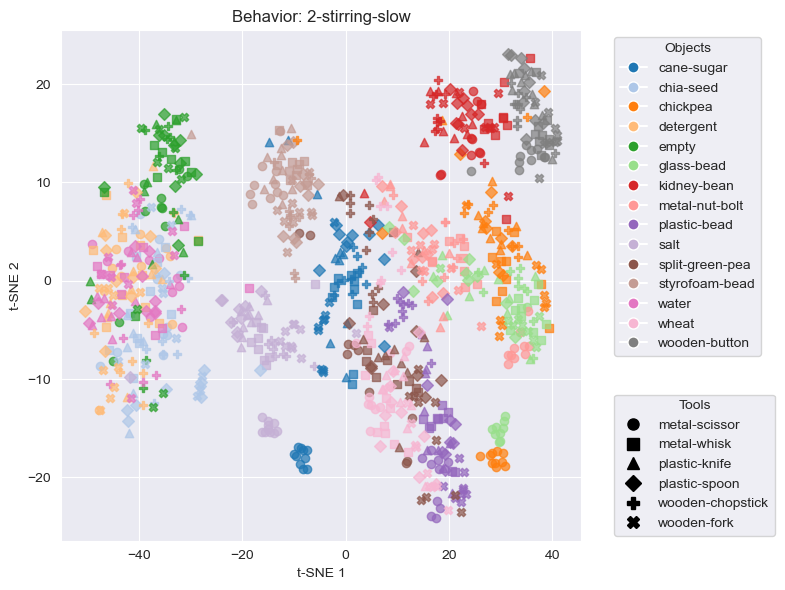

In [23]:
plot_emb_behavior_tsne(emb_dict=emb_dict, behavior_name='2-stirring-slow')

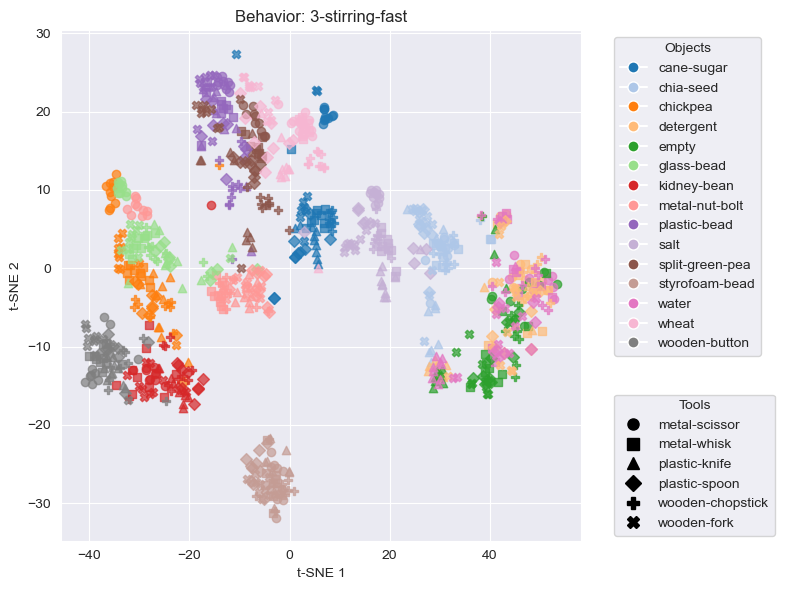

In [24]:
plot_emb_behavior_tsne(emb_dict=emb_dict, behavior_name='3-stirring-fast')

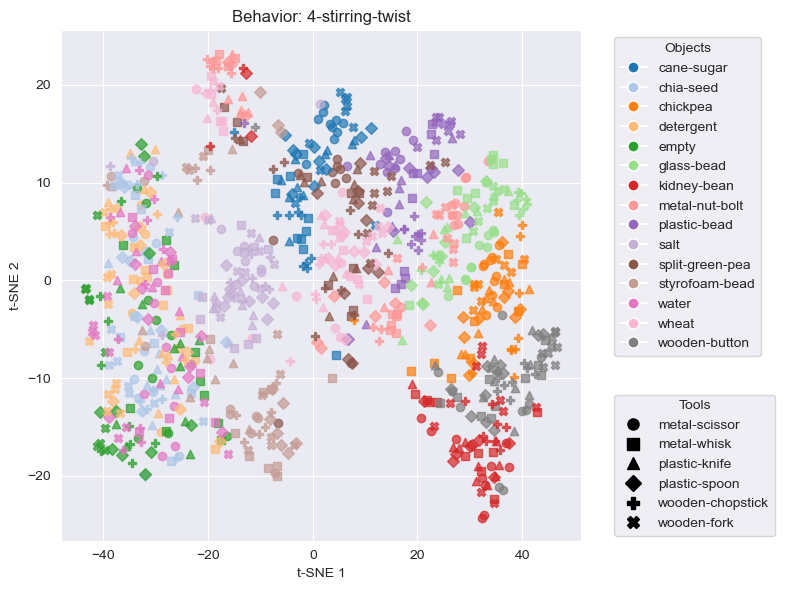

In [25]:
plot_emb_behavior_tsne(emb_dict=emb_dict, behavior_name='4-stirring-twist')

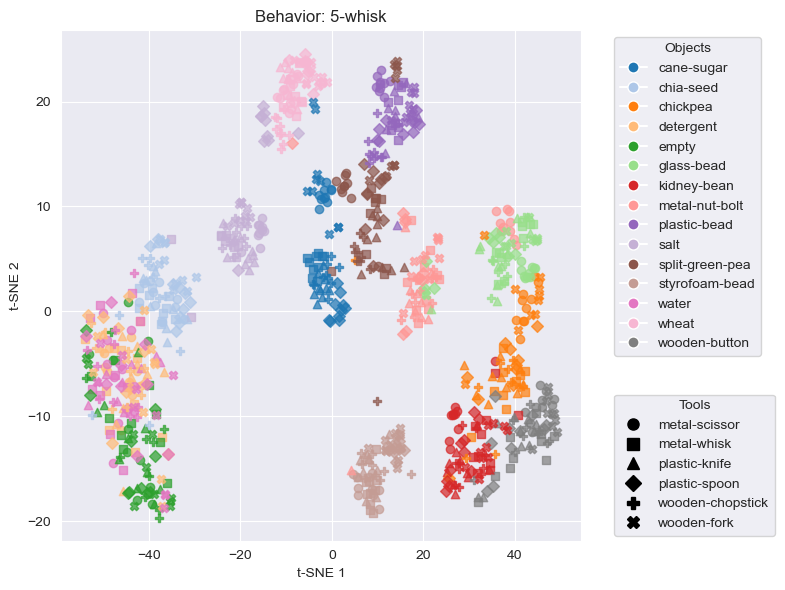

In [26]:
plot_emb_behavior_tsne(emb_dict=emb_dict, behavior_name='5-whisk')

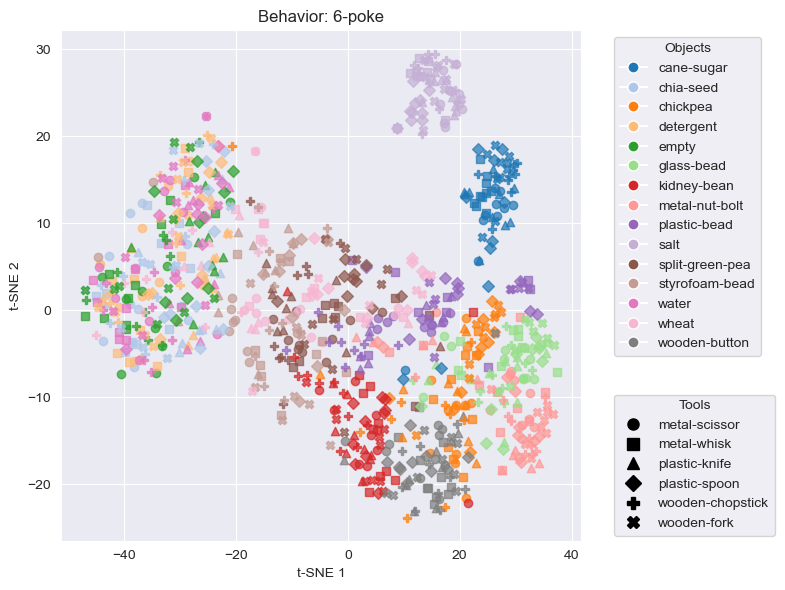

In [27]:
plot_emb_behavior_tsne(emb_dict=emb_dict, behavior_name='6-poke')

# make text embed

In [30]:
def get_interaction_text_emb_dict(tool_list, obj_behavior_list, object_list, text_encoder) -> dict:
    text_emb_dict = {}
    for beh in obj_behavior_list:
        text_emb_dict[beh] = {}
        for tool in tool_list:
            text_emb_dict[beh][tool] = {}
            # map behavior code to natural phrase
            if beh == "2-stirring-slow":
                beh_phrase = "stirred slowly in circular motion"
                beh_verb = "slowly stir"
            elif beh == "3-stirring-fast":
                beh_phrase = "stirred quickly in circular motion"
                beh_verb = "fast stir"
            elif beh == '4-stirring-twist':
                beh_phrase = "stirred and twist quickly  in circular motion"
                beh_verb = "fast stir and twist"
            elif beh == '5-whisk':
                beh_phrase = "whisked back and forth"
                beh_verb = "whisk back and forth"
            elif beh == '6-poke':
                beh_phrase = "poked slowly from above"
                beh_verb = "slowly poke"
            else:
                beh_phrase = beh  # fallback if new behaviors appear
                beh_verb = beh

            for obj in object_list:
                # multiple natural templates (paraphrases)
                candidates = [
                    f"{obj} in a container being {beh_phrase} with a {tool}.",
                    f"A {tool} is used to {beh_verb} {obj} in a container.",
                    f"Sound of {obj} when {beh_phrase} using a {tool}.",
                ]
                # average embeddings from multiple templates
                txt_embs = [text_encoder(desc).squeeze() for desc in candidates]
                txt_emb = sum(txt_embs) / len(txt_embs)
                text_emb_dict[beh][tool][obj] = txt_emb
    return text_emb_dict


In [33]:
ALL_TOOL_LIST = ['metal-scissor', 'metal-whisk', "plastic-knife", 'plastic-spoon', "wooden-chopstick", 'wooden-fork']
ALL_BEH_LIST = ['2-stirring-slow', '3-stirring-fast', '4-stirring-twist', '5-whisk', '6-poke']
SORTED_OBJ_LIST = sorted(['empty', 'water', 'detergent', 'chia-seed', 'cane-sugar', 'salt',
                          'styrofoam-bead', 'split-green-pea', 'wheat', 'chickpea', 'kidney-bean',
                          'wooden-button', 'plastic-bead', 'glass-bead', 'metal-nut-bolt'])
text_emb_dict = get_interaction_text_emb_dict(tool_list=ALL_TOOL_LIST, obj_behavior_list=ALL_BEH_LIST,
                                              object_list=SORTED_OBJ_LIST, text_encoder=model.get_text_embedding)

In [39]:
import torch
for b in ALL_BEH_LIST:
    for t in ALL_TOOL_LIST:
        for o in SORTED_OBJ_LIST:
            text_emb_dict[b][t][o] = np.array(torch.nn.functional.normalize(torch.tensor(text_emb_dict[b][t][o]).unsqueeze(0), dim=-1).squeeze(0))

/var/folders/c8/h_c97cm93kn7mp_xy9k980qm0000gn/T/ipykernel_5738/3364339578.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  text_emb_dict[b][t][o] = np.array(torch.nn.functional.normalize(torch.tensor(text_emb_dict[b][t][o]).unsqueeze(0), dim=-1).squeeze(0))


In [40]:
text_emb_dict['2-stirring-slow']['metal-scissor']['empty'].shape   

(512,)

In [41]:
# np.savez("clap_text_emb_all.npz", **text_emb_dict)

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def flatten_text_emb_dict(text_emb_dict):
    rows = []
    for beh, tools in text_emb_dict.items():
        for tool, objs in tools.items():
            for obj, emb in objs.items():
                rows.append({
                    "behavior": beh,
                    "tool": tool,
                    "object": obj,
                    "embedding": emb.detach().cpu().numpy() if hasattr(emb, "detach") else np.array(emb)
                })
    return pd.DataFrame(rows)

def plot_text_emb_dict_two_views(text_emb_dict, size=80):
    df = flatten_text_emb_dict(text_emb_dict)

    # Stack embeddings
    X = np.stack(df["embedding"].to_numpy())

    # Reduce to 2D
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)
    df["x"] = X_2d[:, 0]
    df["y"] = X_2d[:, 1]

    # Assign colors (object categories)
    obj_categories = df["object"].astype("category")
    df["color"] = obj_categories.cat.codes
    cmap = plt.cm.get_cmap("tab20", len(obj_categories.cat.categories))

    # Object legend (colors)
    from matplotlib.patches import Patch
    obj_handles = [Patch(color=cmap(i), label=obj) for i, obj in enumerate(obj_categories.cat.categories)]

    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

    # ---- Plot 1: shape by tool ----
    tool_list = sorted(df["tool"].unique())
    tool_marker_map = {t: markers[i % len(markers)] for i, t in enumerate(tool_list)}

    plt.figure(figsize=(10, 8))
    for tool, subdf in df.groupby("tool"):
        plt.scatter(
            subdf["x"], subdf["y"],
            c=subdf["color"], cmap=cmap,
            s=size,
            marker=tool_marker_map[tool],
            label=tool,
            alpha=0.8, edgecolors="k"
        )

    # First legend = tool (shapes)
    tool_legend = plt.legend(title="Tool", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.gca().add_artist(tool_legend)

    # Second legend = objects (colors), placed below tool legend
    plt.legend(handles=obj_handles, title="Object", bbox_to_anchor=(1.05, 0.25), loc="lower left",
               fontsize=8, ncol=1)

    plt.title("t-SNE of Text Embeddings\nColor=Object, Shape=Tool")
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: shape by behavior ----
    beh_list = sorted(df["behavior"].unique())
    beh_marker_map = {b: markers[i % len(markers)] for i, b in enumerate(beh_list)}

    plt.figure(figsize=(10, 8))
    for beh, subdf in df.groupby("behavior"):
        plt.scatter(
            subdf["x"], subdf["y"],
            c=subdf["color"], cmap=cmap,
            s=size,
            marker=beh_marker_map[beh],
            label=beh,
            alpha=0.8, edgecolors="k"
        )

    # First legend = behavior (shapes)
    beh_legend = plt.legend(title="Behavior", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.gca().add_artist(beh_legend)

    # Second legend = objects (colors), placed below behavior legend
    plt.legend(handles=obj_handles, title="Object", bbox_to_anchor=(1.05, 0.25), loc="lower left",
               fontsize=8, ncol=1)

    plt.title("t-SNE of Text Embeddings\nColor=Object, Shape=Behavior")
    plt.tight_layout()
    plt.show()

/var/folders/c8/h_c97cm93kn7mp_xy9k980qm0000gn/T/ipykernel_5738/22999064.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", len(obj_categories.cat.categories))


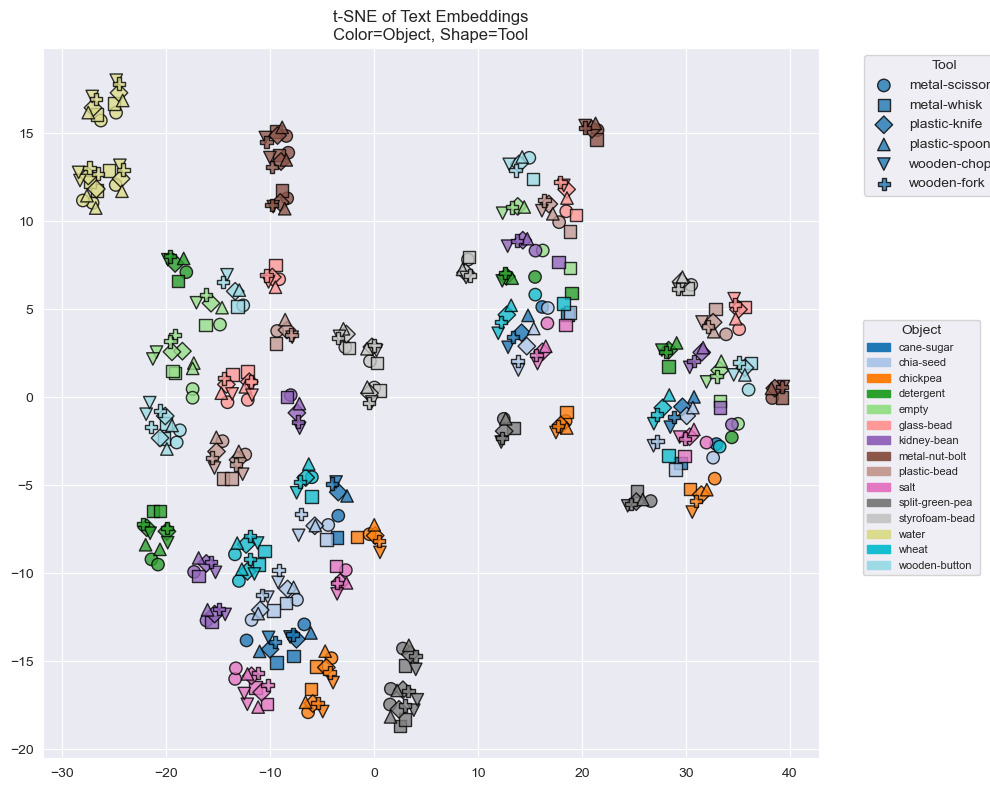

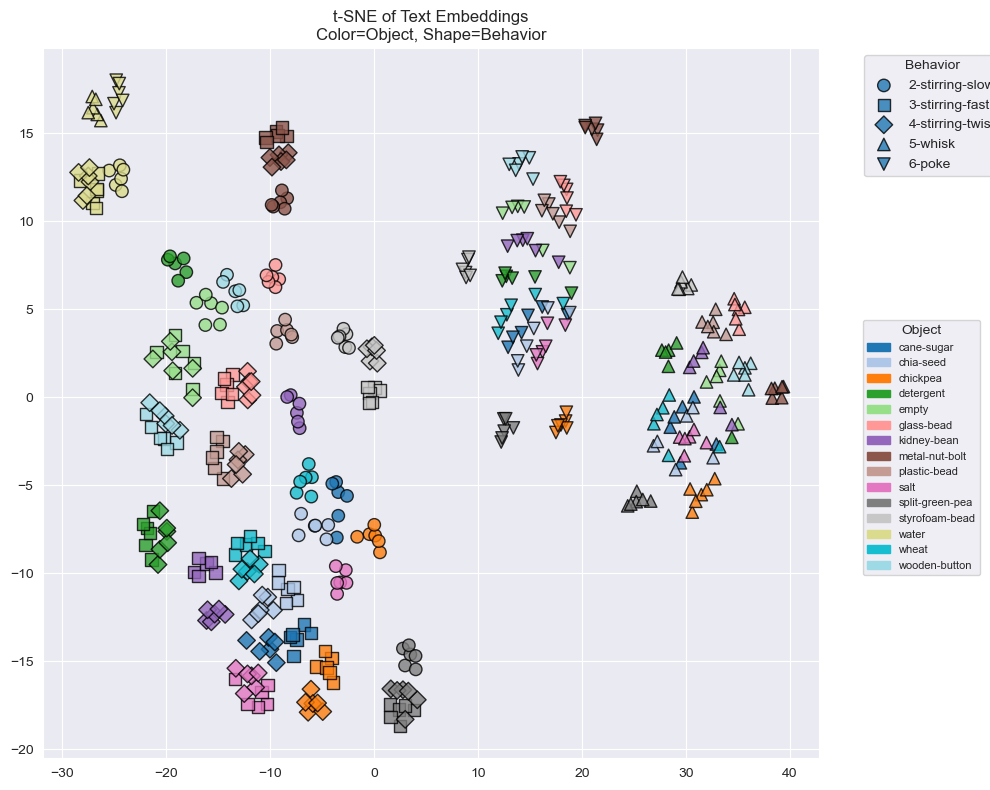

In [57]:

plot_text_emb_dict_two_views(text_emb_dict)